# Magangin — Data Cleaning Pipeline

**Tujuan:** Membersihkan dataset hasil scraping `magangin_jobs_20260510_1527.csv` agar siap
digunakan untuk analisis dan pengembangan fitur rekomendasi magang.

Pembersihan mencakup:
- Menghapus noise pada kolom `company_name` (pola "ulasan" dari Glints/Kalibrr)
- Mengisi nilai null `company_name` dengan ekstraksi dari `link`
- Mengisi null `location_raw` dengan string kosong
- Menambahkan flag `is_clean`

---

## Daftar Isi
1. [Load Data](#1-load-data)
2. [Assess — Before Cleaning](#2-assess--before-cleaning)
3. [Fix company_name](#3-fix-company_name)
4. [Handle Nulls](#4-handle-nulls)
5. [Validate — After Cleaning](#5-validate--after-cleaning)
6. [Drop Kolom](#6-drop-kolom-yang-tidak-dibutuhkan)
7. [Handle Missing Skills](#7-handle-missing-skills--roadmap-mapping)
8. [Validate Final](#8-validate--after-full-cleaning)
9. [Save Output](#9-save-output)

## 1. Load Data

Import library yang dibutuhkan dan muat dataset dari path relatif.
Kita tampilkan shape dan 3 baris pertama untuk memastikan data berhasil dimuat.

In [48]:
import pandas as pd
import re
import numpy as np

RAW_PATH = "../data/magangin_jobs_20260510_1527.csv"
df = pd.read_csv(RAW_PATH)

In [49]:
ORIGINAL_ROW_COUNT = len(df)   

print(f"Shape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print()
df.head()

Shape  : (189, 17)
Kolom  : ['source', 'title', 'link', 'location_raw', 'company_name', 'description_raw', 'skills', 'skills_count', 'role', 'location_city', 'region', 'jogja_tag', 'jabodetabek_tag', 'scraped_at', 'roadmap_url', 'is_tech', 'score']



,source,title,link,location_raw,company_name,description_raw,skills,skills_count,role,location_city,region,jogja_tag,jabodetabek_tag,scraped_at,roadmap_url,is_tech,score
0,jobstreet,Software Developer,https://id.jobstreet.com/id/job/91908572,Jakarta Raya,PT Swadharma Duta Data,Kami saat ini sedang mencari Software Develope...,"agile, android, angular, api, aws, ci/cd, cicd...",27,it-general,jakarta,Jabodetabek,False,True,2026-05-10 15:00:05,https://roadmap.sh/computer-science,True,87
1,jobstreet,Junior Software Engineer,https://id.jobstreet.com/id/job/91648206,Jakarta Raya,PT Technet Vision Indonesia,Qualifications\n\nCore Requirements\n\nBachelo...,"agile, angular, api, aws, cicd, css, docker, g...",20,backend,jakarta,Jabodetabek,False,True,2026-05-10 14:59:42,https://roadmap.sh/backend,True,66
2,jobstreet,Full Stack AI Developer,https://id.jobstreet.com/id/job/91502813,Jakarta Pusat,PT Kharsima Alpha Teknologi,About the Role\n\nWe are looking for a Full St...,"api, aws, azure, cicd, css, database, django, ...",20,backend,jakarta,Jabodetabek,False,True,2026-05-10 15:11:03,https://roadmap.sh/backend,True,66
3,jobstreet,Backend Programmer,https://id.jobstreet.com/id/job/92000167,Jakarta Raya,PT Nutech Integrasi,"Position Objective:\n\nTo develop, maintain, a...","accessibility, api, css, database, express, gi...",19,backend,jakarta,Jabodetabek,False,True,2026-05-10 14:58:48,https://roadmap.sh/backend,True,63
4,jobstreet,Software Engineer Internship,https://id.jobstreet.com/id/job/91761487,Tangerang,OPPO Indonesia,Contract Duration: 3 Months (May - July 2026)\...,"api, css, database, fastapi, git, go, java, ja...",16,it-general,tangerang,Jabodetabek,False,True,2026-05-10 14:57:54,https://roadmap.sh/computer-science,True,57


# Assess 

In [50]:
from jcopml.plot import plot_missing_value

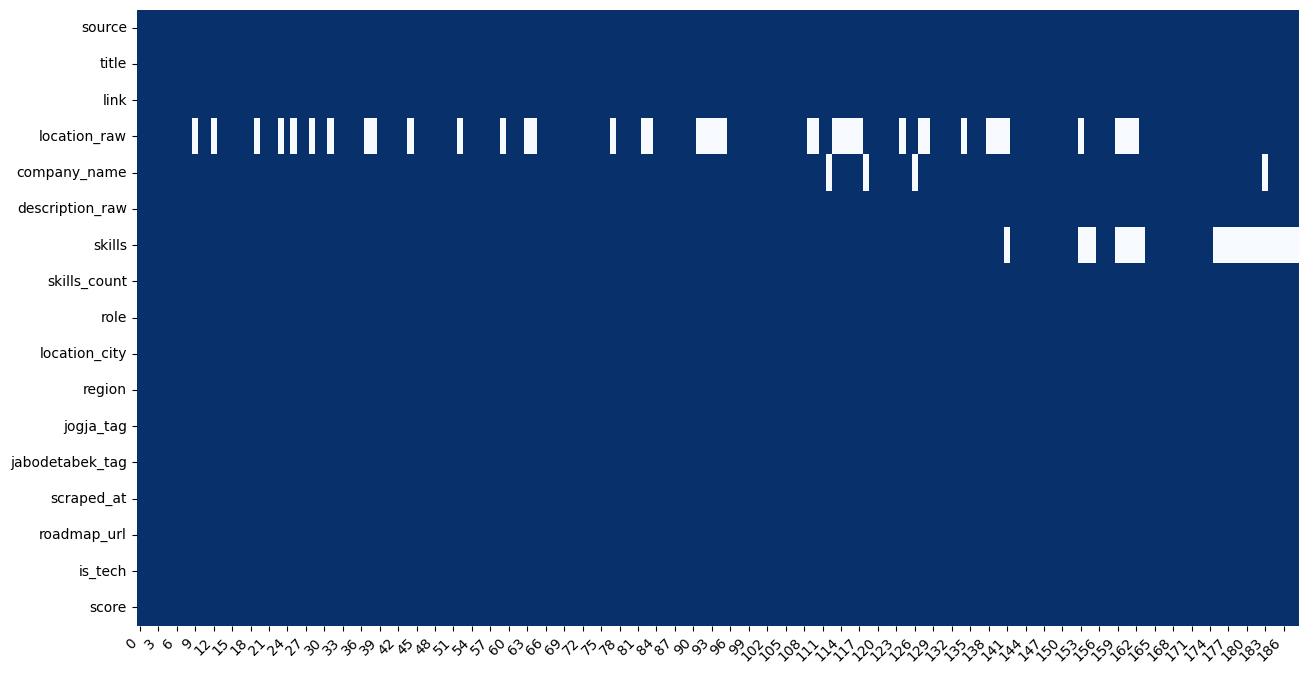

In [51]:
plot_missing_value(df)

In [52]:
# ---------------------------------------------------------------------------
# 2a. Missing values per kolom (hanya yang > 0)
# ---------------------------------------------------------------------------
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

print("=" * 45)
print(" Missing Values per Kolom (hanya > 0)")
print("=" * 45)
if missing_nonzero.empty:
    print("  ✅ Tidak ada nilai null.")
else:
    print(missing_nonzero.to_string())
print()

# ---------------------------------------------------------------------------
# 2b. Jumlah company_name yang mengandung pola "ulasan"
# ---------------------------------------------------------------------------
ulasan_mask = df["company_name"].fillna("").str.contains(r"\d+\s*ulasan", case=False, regex=True)
print(f"company_name mengandung pola 'ulasan' : {ulasan_mask.sum()} baris")
print()

# ---------------------------------------------------------------------------
# 2c. Contoh baris bermasalah
# ---------------------------------------------------------------------------
print("=" * 45)
print(" Contoh: company_name noise (ulasan)")
print("=" * 45)
display(df.loc[ulasan_mask, ["company_name", "link", "source"]].head(5))

print("=" * 45)
print(" Contoh: baris dengan company_name null")
print("=" * 45)
null_company = df["company_name"].isnull()
if null_company.any():
    display(df.loc[null_company, ["company_name", "link", "source"]].head(5))
else:
    print("  Tidak ada company_name yang null.")

print("=" * 45)
print(" Contoh: baris dengan location_raw null")
print("=" * 45)
null_loc = df["location_raw"].isnull()
if null_loc.any():
    cols = [c for c in ["company_name", "location_raw", "location_city"] if c in df.columns] 
    display(df.loc[null_loc, cols].head(5))

    print("  Tidak ada location_raw yang null.")

 Missing Values per Kolom (hanya > 0)
location_raw    42
company_name     4
skills          23

company_name mengandung pola 'ulasan' : 0 baris

 Contoh: company_name noise (ulasan)


,company_name,link,source


 Contoh: baris dengan company_name null


,company_name,link,source
112,NaN,https://id.jobstreet.com/id/job/90477881,jobstreet
118,NaN,https://id.jobstreet.com/id/job/91803680,jobstreet
126,NaN,https://id.jobstreet.com/id/job/91887796,jobstreet
183,NaN,https://id.jobstreet.com/id/job/91978016,jobstreet


 Contoh: baris dengan location_raw null


,company_name,location_raw,location_city
9,CRISBAR,NaN,bandung
12,Glints Taploker,NaN,jakarta
19,PT Sigma Global Teknologi,NaN,jakarta
23,Công Ty Chứng Khoán Phú Hưng,NaN,kediri
25,DATA POLIS,NaN,jakarta


  Tidak ada location_raw yang null.


## 3. Fix company_name

**Strategi pembersihan (berurutan):**

1. **Regex strip** — hapus pola `<angka> ulasan` dari string `company_name` (noise dari Glints).
2. **Strip whitespace** — bersihkan spasi sisa di awal/akhir.
3. **Fallback dari `link`** — jika masih null setelah langkah 1–2, ekstrak nama perusahaan dari URL:
   - **Kalibrr**: pola `/c/<slug>/jobs/` → slug di-title-case, `-` → spasi
   - **Glints**: pola `/companies/<slug>/` → idem
4. **Default** — jika tidak ada pola yang cocok → `"Unknown"`

In [53]:
# ---------------------------------------------------------------------------
# Simpan salinan kolom asli untuk perbandingan
# ---------------------------------------------------------------------------
original_company = df["company_name"].copy()

# ---------------------------------------------------------------------------
# 3a. Hapus pola "\d+ ulasan" (case-insensitive)
# ---------------------------------------------------------------------------
df["company_name"] = df["company_name"].fillna("").str.replace(
    r"\s*\d+\s*ulasan", "", case=False, regex=True
)


# ---------------------------------------------------------------------------
# 3b. Strip whitespace sisa
# ---------------------------------------------------------------------------
df["company_name"] = df["company_name"].str.strip()

# Ubah string kosong hasil strip menjadi NaN agar fallback bisa jalan
df["company_name"] = df["company_name"].replace("", np.nan)

# ---------------------------------------------------------------------------
# 3c. Fallback: ekstrak nama dari kolom link
# ---------------------------------------------------------------------------
def extract_company_from_link(link: str) -> str:
    """Ekstrak nama perusahaan dari URL Kalibrr atau Glints."""
    if not isinstance(link, str):
        return "Unknown"

    # Kalibrr: https://www.kalibrr.id/c/<slug>/jobs/...
    m = re.search(r"/c/([^/]+)/jobs", link)
    if m:
        return m.group(1).replace("-", " ").title()

    # Glints: https://glints.com/id/opportunities/jobs/.../companies/<slug>/...
    #         atau https://glints.com/.../companies/<slug>/
    m = re.search(r"/companies/([^/]+)/", link)
    if m:
        return m.group(1).replace("-", " ").title()

    return "Unknown"


null_mask = df["company_name"].isnull()
if null_mask.any():
    df.loc[null_mask, "company_name"] = df.loc[null_mask, "link"].apply(
        extract_company_from_link
    )

# ---------------------------------------------------------------------------
# 3d. Print before vs after untuk baris yang berubah
# ---------------------------------------------------------------------------
changed_mask = original_company.fillna("") != df["company_name"].fillna("")
changed_count = changed_mask.sum()

print(f"Jumlah baris yang berubah : {changed_count}")
print()

if changed_count > 0:
    comparison = pd.DataFrame({
        "BEFORE": original_company[changed_mask].values,
        "AFTER" : df.loc[changed_mask, "company_name"].values,
        "link"  : df.loc[changed_mask, "link"].values,
    })
    print("=" * 70)
    print(" Before vs After — company_name")
    print("=" * 70)
    display(comparison)

Jumlah baris yang berubah : 4

 Before vs After — company_name


,BEFORE,AFTER,link
0,NaN,Unknown,https://id.jobstreet.com/id/job/90477881
1,NaN,Unknown,https://id.jobstreet.com/id/job/91803680
2,NaN,Unknown,https://id.jobstreet.com/id/job/91887796
3,NaN,Unknown,https://id.jobstreet.com/id/job/91978016


## 4. Handle Nulls

**Keputusan per kolom:**

| Kolom | Perlakuan | Alasan |
|---|---|---|
| `location_raw` | Isi dengan `""` (string kosong) | Diperlukan kolom string; null menyebabkan error downstream |
| `skills` | Biarkan null | Null berarti "skills tidak diketahui", bukan data error |

Selain itu, kita tambahkan kolom `is_clean = True` sebagai flag bahwa baris sudah melewati pipeline cleaning ini.

In [54]:
# ---------------------------------------------------------------------------
# 4a. location_raw null → isi dengan string kosong
# ---------------------------------------------------------------------------
before_loc_null = df["location_raw"].isnull().sum()
df["location_raw"] = df["location_raw"].fillna("")
after_loc_null = df["location_raw"].isnull().sum()

print(f"location_raw null → BEFORE: {before_loc_null}  |  AFTER: {after_loc_null}")

# ---------------------------------------------------------------------------
# 4b. skills null → dibiarkan (tidak diubah)
# ---------------------------------------------------------------------------
print(f"skills null       → TETAP : {df['skills'].isnull().sum()} (tidak diubah)")

# ---------------------------------------------------------------------------
# 4c. Tambah kolom is_clean = True
# ---------------------------------------------------------------------------
df["is_clean"] = True

print()
print(f"Kolom is_clean ditambahkan → semua baris: {df['is_clean'].all()}")
print(f"Shape setelah handle nulls : {df.shape}")

location_raw null → BEFORE: 42  |  AFTER: 0
skills null       → TETAP : 23 (tidak diubah)

Kolom is_clean ditambahkan → semua baris: True
Shape setelah handle nulls : (189, 18)


## 5. Validate — After Cleaning

Langkah validasi untuk memastikan:
- Tidak ada null baru yang muncul secara tidak sengaja
- Jumlah baris tetap **55** (tidak ada yang di-drop)
- Kolom kritis `company_name`, `location_raw`, dan `skills` berstatus sesuai ekspektasi

In [55]:
# ---------------------------------------------------------------------------
# 5a. Missing values per kolom setelah cleaning
# -----------------"----------------------------------------------------------
missing_after = df.isnull().sum()
missing_after_nonzero = missing_after[missing_after > 0]

print("=" * 45)
print(" Missing Values SETELAH Cleaning")
print("=" * 45)
if missing_after_nonzero.empty:
    print("  ✅ Tidak ada nilai null.")
else:
    print(missing_after_nonzero.to_string())
print()

# ---------------------------------------------------------------------------
# 5b. Jumlah baris sebelum vs sesudah
# ---------------------------------------------------------------------------
EXPECTED_ROWS = ORIGINAL_ROW_COUNT  
actual_rows = len(df)
row_status = "✅ OK" if actual_rows == EXPECTED_ROWS else "❌ MISMATCH"

print(f"Jumlah baris sebelum cleaning : {EXPECTED_ROWS}")
print(f"Jumlah baris sesudah cleaning : {actual_rows}  {row_status}")
print()

# ---------------------------------------------------------------------------
# 5c. Null count untuk kolom kritis
# ---------------------------------------------------------------------------
print("=" * 45)
print(" Null Count — Kolom Kritis")
print("=" * 45)
display(
    df[["company_name", "location_raw", "skills"]]
    .isnull()
    .sum()
    .rename("null_count")
    .to_frame()
)

 Missing Values SETELAH Cleaning
skills    23

Jumlah baris sebelum cleaning : 189
Jumlah baris sesudah cleaning : 189  ✅ OK

 Null Count — Kolom Kritis


,null_count
company_name,0
location_raw,0
skills,23


## 6. Drop Kolom yang Tidak Dibutuhkan

Kolom-kolom berikut dihapus karena bersifat **raw/intermediate** dan tidak diperlukan untuk analisis atau rekomendasi:

| Kolom | Alasan Drop |
|---|---|
| `location_raw` | Sudah diekstrak ke `location_city` + `region` |
| `description_raw` | Terlalu panjang, sudah digunakan untuk ekstraksi `skills` |
| `jogja_tag` | Redundan — sudah tercakup dalam `region == 'Yogyakarta'` |
| `jabodetabek_tag` | Redundan — sudah tercakup dalam `region == 'Jabodetabek'` |
| `is_tech` | Redundan — semua baris lolos karena sudah difilter tech-only |
| `score` | Skor pipeline lama, akan dihitung ulang jika diperlukan |

In [56]:
# ---------------------------------------------------------------------------
# 6. Drop kolom yang tidak dibutuhkan
# ---------------------------------------------------------------------------
COLS_TO_DROP = ["location_raw", "description_raw", "jogja_tag", "jabodetabek_tag", "is_tech", "score", "scraped_at", "is_clean"]

# Hanya drop kolom yang memang ada di dataframe
existing_drop = [c for c in COLS_TO_DROP if c in df.columns]
missing_drop  = [c for c in COLS_TO_DROP if c not in df.columns]

df = df.drop(columns=existing_drop)

print(f"Kolom yang di-drop ({len(existing_drop)})  : {existing_drop}")
if missing_drop:
    print(f"Kolom tidak ditemukan (skip)  : {missing_drop}")
print(f"\nShape setelah drop kolom : {df.shape}")
print(f"Kolom tersisa            : {list(df.columns)}")

Kolom yang di-drop (8)  : ['location_raw', 'description_raw', 'jogja_tag', 'jabodetabek_tag', 'is_tech', 'score', 'scraped_at', 'is_clean']

Shape setelah drop kolom : (189, 10)
Kolom tersisa            : ['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']


## 7. Handle Missing Skills — Roadmap Mapping

**Strategi (berurutan):**

1. **Roadmap lookup** — ambil representative skills dari `skills_per_role.json` berdasarkan `role` yang terdeteksi.
   - Role → roadmap key mapping:
     - `data`       → `data-analyst`
     - `ai/ml`      → `ai-data-scientist`
     - `backend`    → `backend`
     - `it-general` → `backend` + `frontend` (IT support butuh kedua sisi)
     - dll
2. **Filter skills** — ambil skills yang ada di `SKILLS_DB` (canonical & relevan), bukan raw roadmap terms.
3. **Drop** — baris yang rolenya tidak bisa di-handle (non-tech / role = `other`).

In [57]:
import json, sys, os
sys.path.insert(0, os.path.abspath(".."))

# ---------------------------------------------------------------------------
# 7a. Load skills_per_role.json dari roadmap output
# ---------------------------------------------------------------------------
ROADMAP_SKILLS_PATH = "../scrapper/roadmap/output/skills_per_role.json"

with open(ROADMAP_SKILLS_PATH, "r", encoding="utf-8") as f:
    ROADMAP_SKILLS = json.load(f)

print(f"Roadmap roles tersedia : {list(ROADMAP_SKILLS.keys())}")
print(f"\nContoh skills 'data-analyst' (5 pertama): {ROADMAP_SKILLS.get('data-analyst', [])[:5]}")

Roadmap roles tersedia : ['frontend', 'backend', 'fullstack', 'devops', 'python', 'javascript', 'typescript', 'react', 'nodejs', 'android', 'ios', 'flutter', 'data-analyst', 'ai-data-scientist', 'mlops', 'cyber-security', 'qa', 'ux-design', 'docker', 'kubernetes']

Contoh skills 'data-analyst' (5 pertama): ['1) predicting sales trends 2) customer segmentation.', 'advanced topics', 'ai and data scientist roadmap', 'analysis / reporting with excel', 'apis']


In [58]:
from scrapper.config import SKILLS_DB, NORMALIZATION_MAP

# ---------------------------------------------------------------------------
# 7b. Buat flat lookup: keyword roadmap → canonical skill name
# ---------------------------------------------------------------------------
VALID_SKILLS = set(SKILLS_DB.keys())

ROADMAP_KW_TO_SKILL = {}
for skill, keywords in SKILLS_DB.items():
    for kw in keywords:
        ROADMAP_KW_TO_SKILL[kw.lower()] = skill

# ---------------------------------------------------------------------------
# 7c. Mapping: role df → roadmap key(s)
# ---------------------------------------------------------------------------
# Catatan: "ai-data-scientist" di skills_per_role.json berisi paper/article/course names
# bukan tech skill terms → tidak ada match ke SKILLS_DB.
# Untuk ai/ml digunakan FALLBACK_SKILLS langsung (hardcoded representatif).
ROLE_TO_ROADMAP_KEYS = {
    "data":       ["data-analyst"],
    "backend":    ["backend"],
    "frontend":   ["frontend"],
    "fullstack":  ["fullstack"],
    "devops":     ["devops"],
    "mobile":     ["android", "flutter", "ios"],
    "qa":         ["qa"],
    "cyber":      ["cyber-security"],
    "ui/ux":      ["ux-design"],
    "it-general": ["backend", "frontend"],   # broad: IT Support/Intern
    # ai/ml → tidak ada roadmap key (ai-data-scientist tidak punya tech terms)
    #         akan langsung pakai FALLBACK_SKILLS
}

# Hardcoded fallback untuk role yang roadmap-nya tidak punya tech skill terms
FALLBACK_SKILLS = {
    "ai/ml": "python, tensorflow, pytorch, sklearn, pandas, numpy, sql, git",
}

def get_skills_from_roadmap(role: str, max_skills: int = 8):
    # Coba roadmap lookup dulu
    roadmap_keys = ROLE_TO_ROADMAP_KEYS.get(role)
    if roadmap_keys:
        found = set()
        for key in roadmap_keys:
            for term in ROADMAP_SKILLS.get(key, []):
                t = term.lower()
                if t in VALID_SKILLS:
                    found.add(t)
                elif t in ROADMAP_KW_TO_SKILL:
                    found.add(ROADMAP_KW_TO_SKILL[t])
        if found:
            return ", ".join(sorted(found)[:max_skills])

    # Fallback hardcoded jika roadmap lookup gagal atau role tidak ada di mapping
    return FALLBACK_SKILLS.get(role, None)


# Uji coba
for test_role in ["data", "ai/ml", "it-general", "backend", "other"]:
    result = get_skills_from_roadmap(test_role)
    print(f"  [{test_role:12s}] → {result}")

  [data        ] → pandas, powerbi, python, pytorch, spark, tableau, tensorflow
  [ai/ml       ] → python, tensorflow, pytorch, sklearn, pandas, numpy, sql, git
  [it-general  ] → accessibility, angular, apollo, astro, bitbucket, cloud, css, database
  [backend     ] → bitbucket, cloud, database, docker, elasticsearch, firebase, git, go
  [other       ] → None


In [59]:
# ---------------------------------------------------------------------------
# 7d. Identifikasi baris dengan skills null
# ---------------------------------------------------------------------------
null_skills_mask = df["skills"].isnull()
null_skills_df   = df[null_skills_mask].copy()

print(f"Baris dengan skills null : {null_skills_mask.sum()}")
print()
print("Title + Role baris tersebut:")
display(
    null_skills_df[["title", "role", "skills"]]
    .reset_index(drop=True)
)

Baris dengan skills null : 23

Title + Role baris tersebut:


,title,role,skills
0,IT Support Intern,it-general,NaN
1,Reporting Social Media Analyst & Data Intern,data,NaN
2,Data Analyst Intern,data,NaN
3,Data Analyst (Internship),data,NaN
4,Graduate Intern - Software Engineer,it-general,NaN
5,IT Intern,it-general,NaN
6,IT Intern,it-general,NaN
7,IT Intern (for Batam placement),it-general,NaN
8,Paid Internship Head Office X DISNAKER,it-general,NaN
9,IT Support Intern,it-general,NaN


In [60]:
# ---------------------------------------------------------------------------
# 7e. Isi skills null dari roadmap mapping, tandai yang gagal
# ---------------------------------------------------------------------------
filled_count = 0
unfilled_idx  = []

for idx in df[null_skills_mask].index:
    role     = df.at[idx, "role"]
    inferred = get_skills_from_roadmap(role)
    if inferred:
        df.at[idx, "skills"]       = inferred
        df.at[idx, "skills_count"] = len(inferred.split(", "))
        filled_count += 1
    else:
        unfilled_idx.append(idx)

print(f"Skills berhasil diisi dari roadmap : {filled_count} baris")
print(f"Skills tidak bisa diisi (akan di-drop) : {len(unfilled_idx)} baris")

if unfilled_idx:
    print("\nBaris yang akan di-drop:")
    display(df.loc[unfilled_idx, ["title", "role", "skills"]])

Skills berhasil diisi dari roadmap : 23 baris
Skills tidak bisa diisi (akan di-drop) : 0 baris


In [61]:
# ---------------------------------------------------------------------------
# 7f. Drop baris yang skills-nya masih null (tidak bisa di-handle)
# ---------------------------------------------------------------------------
before_drop = len(df)

if unfilled_idx:
    df = df.drop(index=unfilled_idx).reset_index(drop=True)

after_drop       = len(df)
remaining_null   = df["skills"].isnull().sum()

print(f"Baris sebelum drop : {before_drop}")
print(f"Baris di-drop      : {before_drop - after_drop}")
print(f"Baris tersisa      : {after_drop}")
print(f"Skills null tersisa: {remaining_null}  {'✅' if remaining_null == 0 else '⚠️ masih ada null'}")
print(f"\nShape final        : {df.shape}")

Baris sebelum drop : 189
Baris di-drop      : 0
Baris tersisa      : 189
Skills null tersisa: 0  ✅

Shape final        : (189, 10)


## 8. Validate — After Full Cleaning

Validasi akhir setelah semua tahap cleaning selesai:
- Tidak ada null pada kolom kritis
- Distribusi role masih wajar
- Kolom final sesuai ekspektasi

In [62]:
# ---------------------------------------------------------------------------
# 8a. Summary missing values final
# ---------------------------------------------------------------------------
missing_final = df.isnull().sum()
missing_final_nonzero = missing_final[missing_final > 0]

print("=" * 50)
print(" Missing Values — FINAL")
print("=" * 50)
if missing_final_nonzero.empty:
    print("  ✅ Tidak ada nilai null pada kolom manapun.")
else:
    print(missing_final_nonzero.to_string())

print()
print("=" * 50)
print(" Distribusi Role")
print("=" * 50)
print(df["role"].value_counts().to_string())

print()
print("=" * 50)
print(" Kolom Final")
print("=" * 50)
print(list(df.columns))
print(f"\nShape final : {df.shape}")

 Missing Values — FINAL
  ✅ Tidak ada nilai null pada kolom manapun.

 Distribusi Role
role
backend       40
it-general    35
cyber         20
frontend      19
qa            19
data          14
ai/ml         13
ui/ux         10
fullstack      9
devops         8
mobile         2

 Kolom Final
['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']

Shape final : (189, 10)


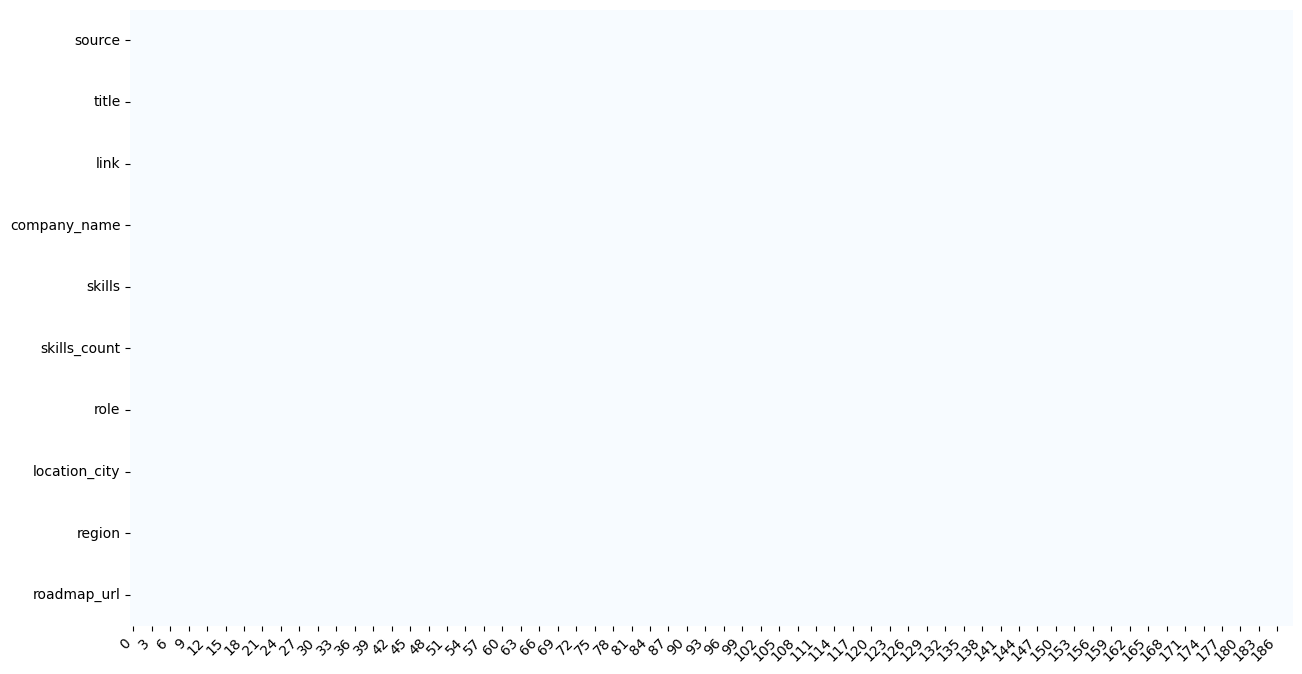

In [63]:
# ---------------------------------------------------------------------------
# 8b. Sample output
# ---------------------------------------------------------------------------
df.head()
plot_missing_value(df)

## 9. Save Output

Simpan dataframe yang sudah bersih ke file baru **tanpa** menimpa file asli.

- Output: `../data/magangin_jobs_cleaned.csv`
- Encoding: `utf-8-sig` (BOM) agar Excel membacanya dengan benar
- File asli `magangin_jobs_20260510_1527.csv` **tidak disentuh**

In [65]:
import os

OUTPUT_PATH = "../data/magangin_jobs_cleaned.csv"

# Guardrail: pastikan tidak menimpa file raw
assert OUTPUT_PATH != RAW_PATH, "Output path sama dengan file asli! Batalkan."

# Simpan
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

# Konfirmasi
abs_path   = os.path.abspath(OUTPUT_PATH)
saved_rows = len(pd.read_csv(OUTPUT_PATH))

print("File berhasil disimpan!")
print(f"   Path  : {abs_path}")
print(f"   Baris : {saved_rows} baris tersimpan")
print(f"   Kolom : {list(df.columns)}")
print()
print("=" * 55)
print(" Ringkasan Pipeline Cleaning")
print("=" * 55)
print(f"  Baris awal (raw)              : {ORIGINAL_ROW_COUNT}")
print(f"  Kolom di-drop                 : {len(existing_drop)} kolom → {existing_drop}")
print(f"  Skills diisi dari roadmap     : {filled_count} baris")
print(f"  Baris di-drop (tidak bisa diisi): {before_drop - after_drop} baris")
print(f"  Baris final tersimpan         : {saved_rows} baris")

File berhasil disimpan!
   Path  : /Users/admin/Desktop/noobies/DBS DS/magangin/data/magangin_jobs_cleaned.csv
   Baris : 189 baris tersimpan
   Kolom : ['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']

 Ringkasan Pipeline Cleaning
  Baris awal (raw)              : 189
  Kolom di-drop                 : 8 kolom → ['location_raw', 'description_raw', 'jogja_tag', 'jabodetabek_tag', 'is_tech', 'score', 'scraped_at', 'is_clean']
  Skills diisi dari roadmap     : 23 baris
  Baris di-drop (tidak bisa diisi): 0 baris
  Baris final tersimpan         : 189 baris
